In [45]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from src.utilities import timer
from src.forward import forward
from src.plot.plot_tools import plot_seismogram

from src.reflectivity_kx_omega import reflectivity
from src.fortran.reflectivity_benchmark import fortran_reflectivity

from src.config import Config
from src.builders import build_problem
from src.layers import create_layers_from_interfaces

In [47]:
config = Config(n_receivers=128, noise_level=0.1, x_min=0., x_max=700.,
                   z_rec=75., z_src=50., x_src=100., nq_prop=1024, f0=10.,
                   total_time=1.024, delay=0.1, epsilon=1.0, source_deriv=True, free_surface=True)
param, acq = build_problem(config)

In [48]:
# example from TOYxDAC_TIME
z_interfaces = np.array([0.0, 100.0, 200.0, 250.0, 350.0, 450.0, 550.0, 650.0, 700.0])
vp = np.array([1505.0, 1603.0, 1749.0, 2019.0, 2179.0,
                   1900.0, 2265.0, 3281.0])
rho = np.full_like(vp, 2000.0)
layers = create_layers_from_interfaces(z_interfaces, vp, rho)

In [49]:
nthetas = 1024
thetas = np.linspace(0., np.pi/2., nthetas)
omegas = 2*np.pi * np.linspace(0.1, 20, 2048) + config.epsilon*1j

with timer("numpy reflectivity"):
    Rmap = reflectivity(layers, omegas + 0.1*1j, thetas, 76., 76., mode="k0",  use_numba=True, fs=True) 

p = np.sin(thetas) / layers[0][1]
with timer("Fortran reflectivity"):
    R_f = fortran_reflectivity(layers, omegas, p, free_surface=1, zr=76., zs=76.)

fixed_omega = 80.
omega_idx = np.argmin(np.abs(omegas - fixed_omega))
R_at_omega = np.abs(R_f[omega_idx, :])

omega_min = np.real(omegas[0])
omega_max = np.real(omegas[-1])
deg_min = 180.*thetas[0]/np.pi
deg_max = 180.*thetas[-1]/np.pi

elapsed: 1.67 s
numpy reflectivity elapsed: 1.69 s
Fortran reflectivity elapsed: 0.18 s


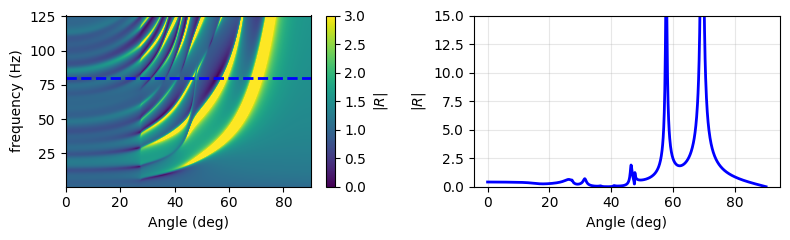

In [50]:
plt.figure(figsize=(8,2.5))
plt.subplot(1,2,1)
plt.imshow(np.abs(Rmap), origin='lower',
            extent=(deg_min, deg_max, omega_min, omega_max),
            aspect='auto',
            vmin=0, vmax=3.0)
plt.axhline(y=fixed_omega, color='blue', linestyle='--', linewidth=2)
plt.xlabel('Angle (deg)')
plt.ylabel('frequency (Hz)')
plt.colorbar(label='$|R|$')

plt.subplot(1,2,2)

plt.plot(180.*thetas/np.pi, R_at_omega, 'b-', linewidth=2)

plt.xlabel('Angle (deg)')
plt.ylabel('$|R|$')
plt.grid(True, alpha=0.3)
plt.ylim([0, 15.0])
plt.tight_layout()
plt.show()

In [51]:
import numba
print("numba is using ", numba.get_num_threads() , " threads")

numba is using  22  threads


In [52]:
d_cal, _ = forward(layers, config, timing=True)

Sommerfeld quadrature elapsed: 1.12 s


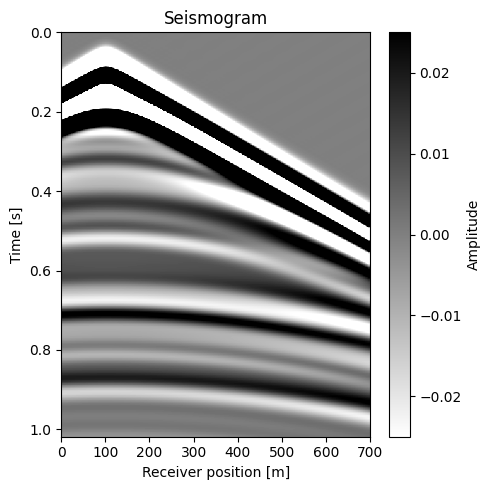

In [53]:
d_cal_seis = d_cal[0, :, :]
d_cal_seis = d_cal_seis / np.max(np.abs(d_cal_seis))  # normalize for better visualization
plot_seismogram(d_cal_seis.T, acq.xr, param.time, vmin=-0.025, vmax=0.025, cmap='gray_r', ncolors=256, figsize=(5, 5))
#plt.savefig("seismogram_reflectivity.png", bbox_inches='tight')

(128, 164)


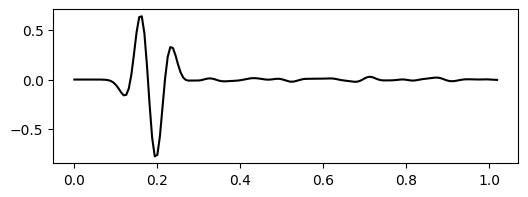

In [54]:
print(d_cal_seis.shape)
plt.figure(figsize=(6, 2))
plt.plot(param.time, d_cal_seis[0, :], 'k-')
plt.show()
#np.savetxt("../FD_comparison/d_cal_seis.txt", d_cal_seis)

(2048,)


Text(0.5, 0, 'Time (s)')

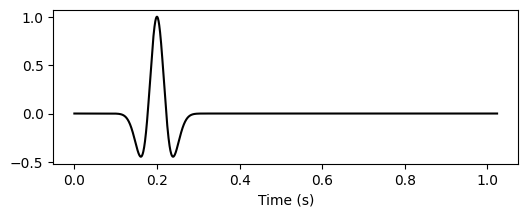

In [55]:
from src.utilities import ricker_wavelet
dt = 0.0005
nt = 2048
time = np.arange(nt) * dt
source_time = ricker_wavelet(time, config.f0)
print(source_time.shape)
plt.figure(figsize=(6, 2))
plt.plot(time, source_time, 'k-')
plt.xlabel('Time (s)')

#source_32 = source_time.astype(np.float32)
# Save to binary file
#filename = "fricker.bin"
#source_32.tofile(filename)
#print(f"File {filename} saved with {source_32.nbytes} bytes.")